# Comparacion de Modelos

---

**Dataset:** [Nombre del dataset]

---

## Que hacemos en este modulo?

El Feature Engineering nos entrego `X_train`, `X_test`, `y_train`, `y_test` listos.
Antes de comprometernos con un modelo definitivo en el Notebook de Modelado,
comparamos varios candidatos usando la misma base de datos y el mismo criterio.

| Paso | Descripcion |
|---|---|
| 1 | Importar librerias y cargar datos del FE |
| 2 | Definir el preprocessor compartido |
| 3 | Definir los modelos candidatos |
| 4 | Entrenar y evaluar todos con validacion cruzada |
| 5 | Comparar resultados visualmente |
| 6 | Analisis de tiempo de entrenamiento |
| 7 | Decision final: cual modelo pasa al Modelado |

> **Regla de oro:** El ganador no siempre es el de mayor R2.
> El mejor modelo es el que combina buen desempeno, estabilidad entre folds
> y tiempo de entrenamiento razonable para el contexto del proyecto.

---


---
## Paso 1 — Importar librerias

| Libreria / Modulo | Para que la usamos |
|---|---|
| `pandas` / `numpy` | Manipulacion de datos y resultados |
| `matplotlib` / `seaborn` | Visualizar comparaciones entre modelos |
| `sklearn.linear_model` | Modelos lineales: LinearRegression, Ridge, Lasso |
| `sklearn.tree` | Arboles de decision |
| `sklearn.ensemble` | Modelos de ensamble: RandomForest, GradientBoosting |
| `sklearn.model_selection` | Validacion cruzada: cross_val_score, KFold |
| `sklearn.pipeline` | Construir pipelines por modelo |
| `time` | Medir tiempo de entrenamiento de cada modelo |

---


In [1]:
# Librerias

import pandas as pd
import numpy as np
import time
import joblib
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler, RobustScaler,
                                   OneHotEncoder, FunctionTransformer)

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor,
                              GradientBoostingRegressor,
                              ExtraTreesRegressor)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# XGBoost (descomenta si lo tienes instalado)
# from xgboost import XGBRegressor

from sklearn.model_selection import cross_val_score, KFold, cross_validate
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Librerias cargadas correctamente')


Librerias cargadas correctamente


---
## Paso 2 — Cargar datos del Feature Engineering

Cargamos los archivos `.parquet` que guardamos al final del Notebook de FE.
Tambien reconstruimos el `preprocessor` con exactamente los mismos
parametros que usamos en el Notebook de Modelado.

> **Por que reconstruir el preprocessor aqui?**
> Porque vamos a crear un Pipeline diferente por cada modelo candidato.
> Cada Pipeline necesita su propio preprocessor para que el `fit` sea
> independiente entre modelos.

---


In [2]:
# Configuraciones

TARGET_COL     = 'Price_log'   # <-- CAMBIA al nombre de tu target
TRANSF_INVERSA = 'log1p'       # <-- CAMBIA segun tu transformacion del FE

In [3]:
# ══ Carga de datos ══

# QUE HACE ESTE BLOQUE
#   Carga X_train, X_test, y_train, y_test desde los archivos parquet
#   del Feature Engineering y define la configuracion base.
#
# POR QUE ES IMPORTANTE
#   Todos los modelos deben evaluarse sobre exactamente los mismos datos
#   y con la misma division train/test. Si cada modelo viera datos
#   diferentes, la comparacion no seria justa.
#
# QUE DEBEMOS ESPERAR
#   Los shapes de X_train y X_test deben coincidir con los del Notebook de FE.
#   Si hay error al leer los parquet, verifica que corriste el paso 11
#   del Notebook de Feature Engineering.
# ═══════════════════════════════════════════════════════════════════════════


def datetime_a_timestamp(X):
    """Convierte columnas datetime a segundos Unix. Necesaria para deserializar el pipeline."""
    return X.apply(lambda col: col.astype('int64') // 10**9).astype(float)

# Cargar datasets
train = pd.read_parquet('work_lineal/train_final.parquet')
test  = pd.read_parquet('work_lineal/test_final.parquet')

X_train = train.drop(columns=[TARGET_COL])
y_train = train[TARGET_COL]
X_test  = test.drop(columns=[TARGET_COL])
y_test  = test[TARGET_COL]

print(f'Datos cargados correctamente')
print(f'   X_train : {X_train.shape[0]:,} filas x {X_train.shape[1]} columnas')
print(f'   X_test  : {X_test.shape[0]:,} filas x {X_test.shape[1]} columnas')
print(f'   y_train : {y_train.shape}')
print(f'   y_test  : {y_test.shape}')


Datos cargados correctamente
   X_train : 10,853 filas x 20 columnas
   X_test  : 2,714 filas x 20 columnas
   y_train : (10853,)
   y_test  : (2714,)


In [4]:
# ══ Definir preprocessor (ColumnTransformer) ══

# QUE HACE ESTE BLOQUE
#   Reconstruye el preprocessor (ColumnTransformer) que se usara como base
#   para todos los pipelines de los modelos candidatos.
#
# POR QUE ES IMPORTANTE
#   El preprocessor debe ser identico al del Notebook de Modelado para
#   garantizar que los datos que recibe cada modelo son exactamente los
#   mismos. Si cambias un escalador aqui, la comparacion deja de ser
#   equivalente a lo que hiciste en Modelado.
#
# QUE DEBEMOS ESPERAR
#   'Preprocessor definido: X transformers' donde X es el numero de
#   grupos de columnas que tienes (num, cat, fecha).
# ═══════════════════════════════════════════════════════════════════════════

# Clasificar columnas igual que en el Notebook de Modelado
num_pipeline_cols  = X_train.select_dtypes(include='number').columns.tolist()
cat_pipeline_cols  = X_train.select_dtypes(include='object').columns.tolist()
date_pipeline_cols = X_train.select_dtypes(include='datetime').columns.tolist()

# Sub-pipelines (identicos al Notebook de Modelado)
pipeline_numericas = Pipeline(steps=[
    ('imputar', SimpleImputer(strategy='median')),
    ('escalar', RobustScaler())
])

pipeline_categoricas = Pipeline(steps=[
    ('imputar',   SimpleImputer(strategy='most_frequent')),
    ('codificar', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

pipeline_fechas = Pipeline(steps=[
    ('a_numero', FunctionTransformer(datetime_a_timestamp)),
    ('escalar',  StandardScaler())
])

# Construir transformers
transformers = [('num', pipeline_numericas, num_pipeline_cols)]
if cat_pipeline_cols:
    transformers.append(('cat', pipeline_categoricas, cat_pipeline_cols))
if date_pipeline_cols:
    transformers.append(('fecha', pipeline_fechas, date_pipeline_cols))

def build_preprocessor():
    """Retorna un preprocessor nuevo (sin fit) para cada modelo candidato."""
    p_num = Pipeline(steps=[
        ('imputar', SimpleImputer(strategy='median')),
        ('escalar', RobustScaler())
    ])
    p_cat = Pipeline(steps=[
        ('imputar',   SimpleImputer(strategy='most_frequent')),
        ('codificar', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    p_fecha = Pipeline(steps=[
        ('a_numero', FunctionTransformer(datetime_a_timestamp)),
        ('escalar',  StandardScaler())
    ])
    t = [('num', p_num, num_pipeline_cols)]
    if cat_pipeline_cols:  t.append(('cat',   p_cat,   cat_pipeline_cols))
    if date_pipeline_cols: t.append(('fecha', p_fecha, date_pipeline_cols))
    return ColumnTransformer(transformers=t, remainder='passthrough')

print(f'Preprocessor definido: {len(transformers)} transformers')
print(f'   Numericas   : {len(num_pipeline_cols)} columnas')
print(f'   Categoricas : {len(cat_pipeline_cols)} columnas')
print(f'   Fechas      : {len(date_pipeline_cols)} columnas')


Preprocessor definido: 1 transformers
   Numericas   : 20 columnas
   Categoricas : 0 columnas
   Fechas      : 0 columnas


---
## Paso 3 — Definir los modelos candidatos

Definimos todos los modelos que queremos comparar con sus hiperparametros
por defecto. En este punto NO los entrenamos, solo los declaramos.

**Por que empezar con hiperparametros por defecto?**
Porque queremos saber cual familia de modelos funciona mejor ANTES de
invertir tiempo en optimizar hiperparametros. Si RandomForest con defaults
ya supera a GradientBoosting con defaults, ahi enfocamos la optimizacion.

| Modelo | Tipo | Necesita escalado | Captura no-linealidad |
|---|---|---|---|
| LinearRegression | Lineal | Si | No |
| Ridge | Lineal regularizado | Si | No |
| Lasso | Lineal regularizado | Si | No |
| ElasticNet | Lineal regularizado | Si | No |
| DecisionTree | Arbol | No | Si |
| RandomForest | Ensamble (bagging) | No | Si |
| ExtraTrees | Ensamble (bagging) | No | Si |
| GradientBoosting | Ensamble (boosting) | No | Si |
| KNN | Basado en distancia | Si | Si |

---


In [5]:
# ════ Registrar modelos candidatos ═══════════════════════════
# QUE HACE ESTE BLOQUE
#   Define el diccionario de modelos candidatos con sus hiperparametros
#   por defecto. Cada entrada es un nombre y una instancia del modelo.
#
# POR QUE ES IMPORTANTE
#   Usar un diccionario permite iterar sobre todos los modelos con el
#   mismo codigo, sin repetir bloques. Si se quiere agregar un modelo nuevo
#   solo agrega una linea al diccionario.
#   Los modelos de arboles (RandomForest, GradientBoosting) NO necesitan
#   escalado pero lo incluimos en el preprocessor de todas formas:
#   escalar no los dania y mantiene el pipeline uniforme para todos.
#
# QUE DEBEMOS ESPERAR
#   - La lista de modelos registrados con sus nombres.
#   - DECISION POINT: comenta los modelos que no quieras incluir,
#   - o agrega nuevos siguiendo el mismo patron.
# ═══════════════════════════════════════════════════════════════════════════

SEMILLA = 42  # semilla global para reproducibilidad

modelos_candidatos = {
    # ── Modelos lineales ─────────────────────────────────────────────────
    'LinearRegression':  LinearRegression(),
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=0.01),
    'ElasticNet':        ElasticNet(alpha=0.01, l1_ratio=0.5),

    # ── Arboles de decision ───────────────────────────────────────────────
    'DecisionTree':      DecisionTreeRegressor(random_state=SEMILLA),

    # ── Modelos de ensamble (los mas potentes para datos tabulares) ───────
    'RandomForest':      RandomForestRegressor(n_estimators=100, random_state=SEMILLA, n_jobs=-1),
    'ExtraTrees':        ExtraTreesRegressor(n_estimators=100,   random_state=SEMILLA, n_jobs=-1),
    'GradientBoosting':  GradientBoostingRegressor(n_estimators=100, random_state=SEMILLA),

    # ── Basado en distancia ───────────────────────────────────────────────
    'KNN':               KNeighborsRegressor(n_neighbors=5, n_jobs=-1),

    # ── XGBoost (descomenta si tienes xgboost instalado) ─────────────────
    # 'XGBoost':         XGBRegressor(n_estimators=100, random_state=SEMILLA,
    #                                 verbosity=0, n_jobs=-1),
}

print(f'Modelos registrados: {len(modelos_candidatos)}')
for nombre in modelos_candidatos:
    print(f'   {nombre}')


Modelos registrados: 9
   LinearRegression
   Ridge
   Lasso
   ElasticNet
   DecisionTree
   RandomForest
   ExtraTrees
   GradientBoosting
   KNN


---
## Paso 4 — Entrenar y evaluar con validacion cruzada

Para cada modelo candidato construimos un Pipeline completo,
ejecutamos validacion cruzada de 5 folds y registramos:
R2, RMSE, MAE y tiempo de entrenamiento.

> **Por que validacion cruzada y no solo train/test?**
> Porque una sola division puede favorecer a un modelo por azar.
> Con 5 folds, cada modelo se evalua 5 veces con datos diferentes
> y promediamos los resultados. La comparacion es mucho mas justa.

---


In [6]:
# ══════ Evaluacion de modelos ═══════════════════════════
# QUE HACE ESTE BLOQUE
#   Itera sobre cada modelo candidato, construye su Pipeline completo,
#   ejecuta validacion cruzada 5-fold y registra R2, RMSE, MAE y tiempo.
#
# POR QUE ES IMPORTANTE
#   Cada modelo recibe su propio Pipeline con un preprocessor fresco
#   (sin fit previo). Esto garantiza que el preprocessor aprende SOLO
#   del train de cada fold, sin contaminar con datos del fold de test.
#   El tiempo de entrenamiento es un criterio real: un modelo que tarda
#   10 minutos en entrenarse puede ser inviable si necesitas reentrenar
#   diariamente. Lo registramos aqui para tenerlo en la decision final.
#
# QUE DEBEMOS ESPERAR
#   Una barra de progreso por modelo. Los modelos lineales terminan en
#   segundos. RandomForest y GradientBoosting pueden tardar 1-3 minutos.
#   Al final, el diccionario 'resultados' tiene los scores de todos.
# ═══════════════════════════════════════════════════════════════════════════

kf        = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)
resultados = []
pipelines_entrenados = {}  # guardamos cada pipeline para usarlo despues

print('Evaluando modelos... (esto puede tardar unos minutos)')
print('=' * 65)

for nombre, modelo in modelos_candidatos.items():

    # Construir pipeline con preprocessor fresco para este modelo
    pipe = Pipeline(steps=[
        ('preprocesamiento', build_preprocessor()),
        ('modelo', modelo)
    ])

    # Medir tiempo de entrenamiento (fit completo sobre X_train)
    t_inicio = time.time()
    pipe.fit(X_train, y_train)
    t_fin    = time.time()
    tiempo_s = round(t_fin - t_inicio, 2)

    # Validacion cruzada: R2 y RMSE
    scores_r2   = cross_val_score(pipe, X_train, y_train,
                                  cv=kf, scoring='r2', n_jobs=-1)
    scores_rmse = -cross_val_score(pipe, X_train, y_train,
                                   cv=kf,
                                   scoring='neg_root_mean_squared_error',
                                   n_jobs=-1)
    scores_mae  = -cross_val_score(pipe, X_train, y_train,
                                   cv=kf,
                                   scoring='neg_mean_absolute_error',
                                   n_jobs=-1)

    # Evaluar sobre test (para comparar con las metricas del Notebook de Evaluacion)
    y_pred_test = pipe.predict(X_test)
    r2_test     = r2_score(y_test, y_pred_test)
    rmse_test   = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # Gap train vs test (detector de overfitting)
    y_pred_train = pipe.predict(X_train)
    r2_train     = r2_score(y_train, y_pred_train)
    gap          = round(r2_train - r2_test, 4)

    resultados.append({
        'Modelo':         nombre,
        'R2_CV_mean':     round(scores_r2.mean(),   4),
        'R2_CV_std':      round(scores_r2.std(),    4),
        'RMSE_CV_mean':   round(scores_rmse.mean(), 4),
        'RMSE_CV_std':    round(scores_rmse.std(),  4),
        'MAE_CV_mean':    round(scores_mae.mean(),  4),
        'R2_test':        round(r2_test,            4),
        'RMSE_test':      round(rmse_test,          4),
        'Gap_overfit':    gap,
        'Tiempo_s':       tiempo_s,
    })

    pipelines_entrenados[nombre] = pipe

    print(f'{nombre:<22} R2_CV={scores_r2.mean():.4f} +/-{scores_r2.std():.4f} '
          f'| RMSE={scores_rmse.mean():.4f} | Gap={gap:+.4f} | {tiempo_s}s')

print('=' * 65)
print(f'Evaluacion completa: {len(resultados)} modelos evaluados')


Evaluando modelos... (esto puede tardar unos minutos)
LinearRegression       R2_CV=0.7128 +/-0.0103 | RMSE=0.2818 | Gap=+0.0025 | 0.1s
Ridge                  R2_CV=0.7128 +/-0.0103 | RMSE=0.2818 | Gap=+0.0025 | 0.09s
Lasso                  R2_CV=0.6840 +/-0.0072 | RMSE=0.2957 | Gap=+0.0037 | 0.16s
ElasticNet             R2_CV=0.7003 +/-0.0078 | RMSE=0.2880 | Gap=+0.0029 | 0.16s
DecisionTree           R2_CV=0.6763 +/-0.0157 | RMSE=0.2991 | Gap=+0.3046 | 0.21s
RandomForest           R2_CV=0.8265 +/-0.0079 | RMSE=0.2190 | Gap=+0.1400 | 1.18s
ExtraTrees             R2_CV=0.8137 +/-0.0106 | RMSE=0.2269 | Gap=+0.1694 | 1.01s
GradientBoosting       R2_CV=0.8130 +/-0.0091 | RMSE=0.2274 | Gap=+0.0142 | 2.11s
KNN                    R2_CV=0.7170 +/-0.0102 | RMSE=0.2797 | Gap=+0.0932 | 0.05s
Evaluacion completa: 9 modelos evaluados


---
## Paso 5 — Tabla comparativa de resultados

Consolidamos todos los resultados en una tabla ordenada por R2 de
validacion cruzada. Esta tabla es el insumo principal para la decision.

---


In [8]:
# ════════════ Tabla de comparacion ═════════════════════════════════
# QUE HACE ESTE BLOQUE
#   Construye la tabla de comparacion ordenada por R2_CV_mean (de mayor
#   a menor) y la presenta con degradado de color para facilitar la lectura.
#
# POR QUE ES IMPORTANTE
#   Las columnas clave para la decision son:
#   - R2_CV_mean: desempeno promedio en 5 folds (el numero mas honesto)
#   - R2_CV_std:  estabilidad. Menor es mejor. Un modelo con std=0.08
#                 es impredecible aunque tenga buen promedio.
#   - Gap_overfit: diferencia R2_train - R2_test. Mayor a 0.15 es alerta.
#   - Tiempo_s:   tiempo de entrenamiento. Relevante para produccion.
#
# QUE DEBEMOS ESPERAR
#   Los modelos de ensamble (RandomForest, GradientBoosting) tipicamente
#   superan a los lineales en datasets como Melbourne donde hay relaciones
#   no lineales. Si LinearRegression gana, puede indicar que el FE ya
#   capturo bien las relaciones y el dataset es fundamentalmente lineal.
# ═══════════════════════════════════════════════════════════════════════════

df_resultados = (
    pd.DataFrame(resultados)
    .sort_values('R2_CV_mean', ascending=False)
    .reset_index(drop=True)
)
df_resultados.index += 1  # ranking empieza en 1

# Columna de alerta de overfitting
df_resultados['Overfitting'] = df_resultados['Gap_overfit'].apply(
    lambda g: 'ALERTA' if g > 0.15 else 'OK'
)

print('=== TABLA COMPARATIVA DE MODELOS (ordenada por R2 CV) ===')
display(
    df_resultados.style
    .background_gradient(subset=['R2_CV_mean'], cmap='Greens')
    .background_gradient(subset=['R2_CV_std'],  cmap='Reds_r')
    .background_gradient(subset=['Gap_overfit'], cmap='Oranges')
    .background_gradient(subset=['Tiempo_s'],   cmap='Blues_r')
    .map(
        lambda v: 'color: crimson; font-weight: bold' if v == 'ALERTA' else 'color: green',
        subset=['Overfitting']
    )
    .format({
        'R2_CV_mean':  '{:.4f}',
        'R2_CV_std':   '{:.4f}',
        'RMSE_CV_mean':'{:.4f}',
        'Gap_overfit': '{:+.4f}',
        'Tiempo_s':    '{:.1f}s',
    })
)


=== TABLA COMPARATIVA DE MODELOS (ordenada por R2 CV) ===


,Modelo,R2_CV_mean,R2_CV_std,RMSE_CV_mean,RMSE_CV_std,MAE_CV_mean,R2_test,RMSE_test,Gap_overfit,Tiempo_s,Overfitting
1,RandomForest,0.8265,0.0079,0.2190,0.003600,0.162300,0.836400,0.214000,+0.1400,1.2s,OK
2,ExtraTrees,0.8137,0.0106,0.2269,0.005300,0.168400,0.829700,0.218400,+0.1694,1.0s,ALERTA
3,GradientBoosting,0.8130,0.0091,0.2274,0.004100,0.172100,0.810800,0.230200,+0.0142,2.1s,OK
4,KNN,0.7170,0.0102,0.2797,0.004500,0.214300,0.724700,0.277700,+0.0932,0.1s,OK
5,LinearRegression,0.7128,0.0103,0.2818,0.004600,0.218900,0.711700,0.284100,+0.0025,0.1s,OK
6,Ridge,0.7128,0.0103,0.2818,0.004600,0.218900,0.711700,0.284100,+0.0025,0.1s,OK
7,ElasticNet,0.7003,0.0078,0.2880,0.003600,0.224500,0.698400,0.290600,+0.0029,0.2s,OK
8,Lasso,0.6840,0.0072,0.2957,0.003300,0.231500,0.681400,0.298700,+0.0037,0.2s,OK
9,DecisionTree,0.6763,0.0157,0.2991,0.004900,0.221300,0.694500,0.292500,+0.3046,0.2s,ALERTA


---
## Paso 6 — Visualizacion comparativa

La tabla es precisa pero los graficos revelan patrones que los numeros ocultan:
que tan estable es cada modelo entre folds, si hay un ganador claro
o si varios modelos empatan dentro del margen de error.

---


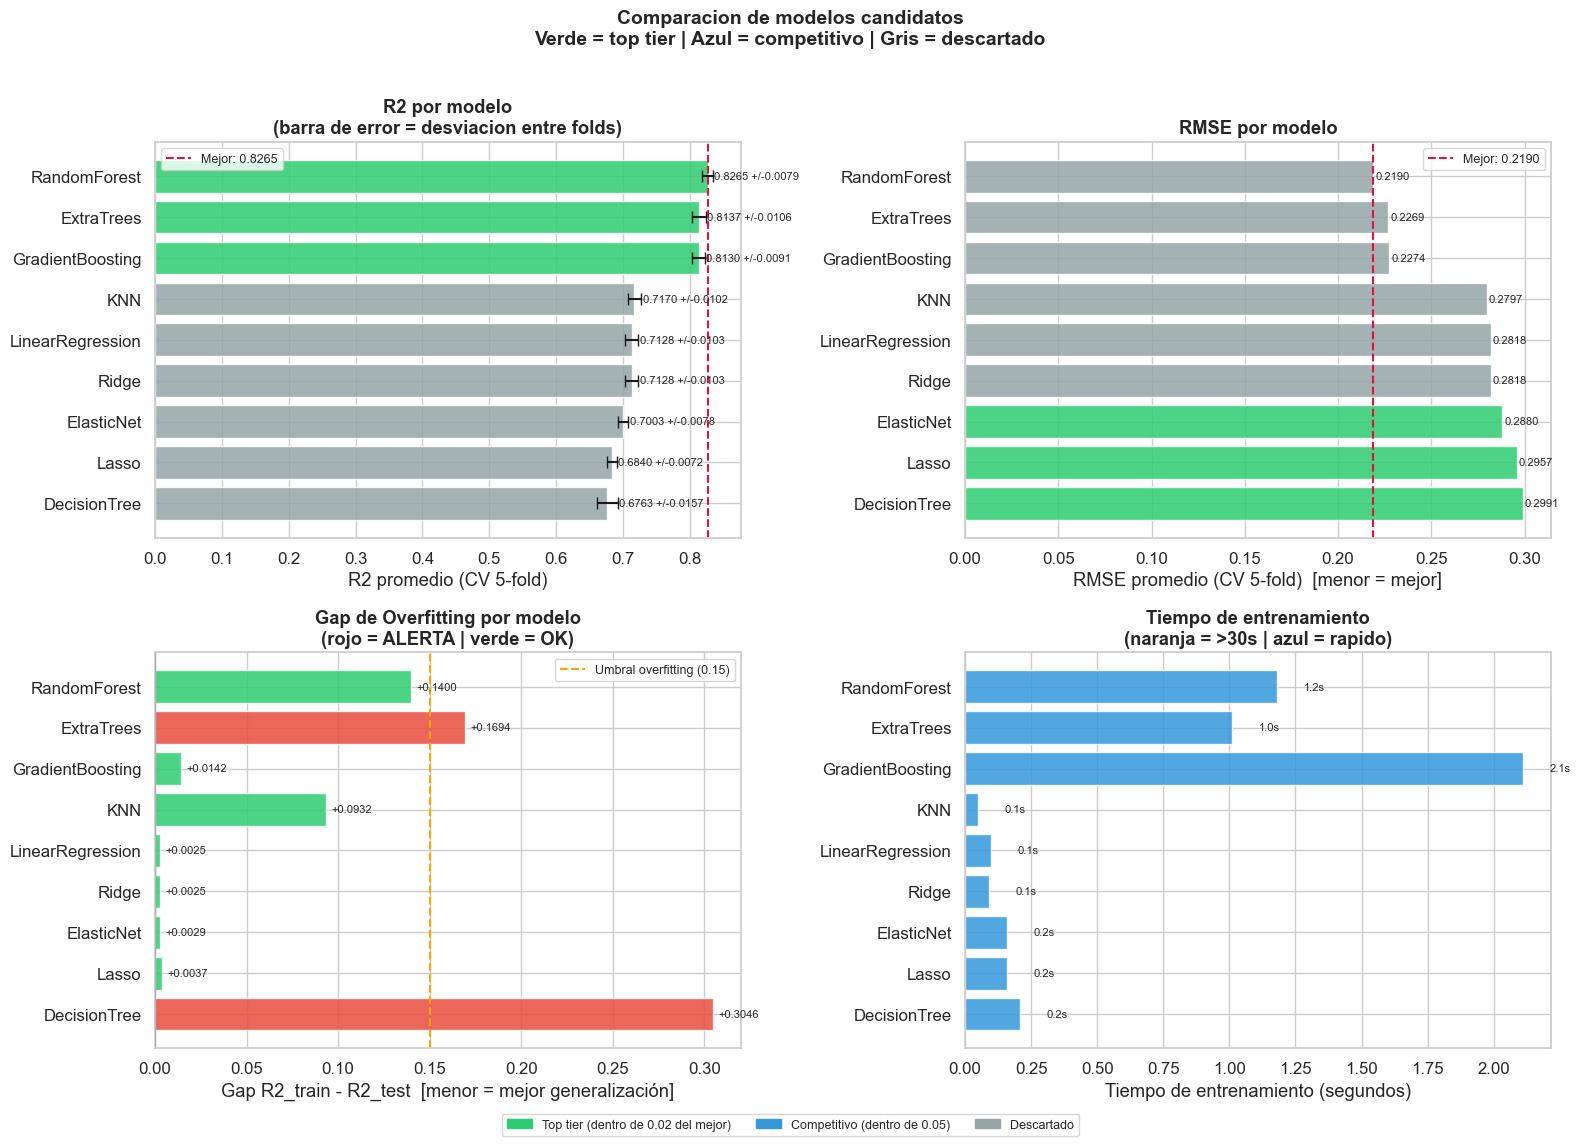

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# QUE HACE ESTE BLOQUE
#   Genera cuatro graficos comparativos: R2 con barras de error (std),
#   RMSE, gap de overfitting y tiempo de entrenamiento.
#
# POR QUE ES IMPORTANTE
#   Las barras de error en el R2 son criticas: si dos modelos tienen
#   R2 similar pero uno tiene barras de error mucho mas cortas, ese
#   es el mas confiable aunque su promedio sea ligeramente menor.
#   El grafico de tiempo permite ver si el modelo mas preciso vale
#   el costo computacional comparado con el segundo mejor.
#
# QUE DEBEMOS ESPERAR
#   Un modelo dominante que tenga barra alta en R2, barra baja en RMSE,
#   gap pequeno en overfitting y tiempo razonable. Si no existe ese
#   modelo perfecto, la decision implica un tradeoff entre estas metricas.
# ═══════════════════════════════════════════════════════════════════════════

nombres  = df_resultados['Modelo'].tolist()
r2_means = df_resultados['R2_CV_mean'].tolist()
r2_stds  = df_resultados['R2_CV_std'].tolist()
rmse_m   = df_resultados['RMSE_CV_mean'].tolist()
gaps     = df_resultados['Gap_overfit'].tolist()
tiempos  = df_resultados['Tiempo_s'].tolist()

colores_base = [
    '#2ecc71' if r >= max(r2_means) - 0.02   # verde: top tier
    else '#3498db' if r >= max(r2_means) - 0.05  # azul: competitivo
    else '#95a5a6'  # gris: descartado
    for r in r2_means
]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── Grafico 1: R2 con barras de error ────────────────────────────────────
bars = axes[0,0].barh(nombres, r2_means, xerr=r2_stds,
                       color=colores_base, alpha=0.85,
                       edgecolor='white', capsize=4)
axes[0,0].axvline(max(r2_means), color='crimson', ls='--', lw=1.5,
                   label=f'Mejor: {max(r2_means):.4f}')
for bar, val, std in zip(bars, r2_means, r2_stds):
    axes[0,0].text(val + std + 0.002, bar.get_y() + bar.get_height()/2,
                   f'{val:.4f} +/-{std:.4f}',
                   va='center', fontsize=8)
axes[0,0].set_xlabel('R2 promedio (CV 5-fold)')
axes[0,0].set_title('R2 por modelo\n(barra de error = desviacion entre folds)',
                     fontweight='bold')
axes[0,0].legend(fontsize=9)
axes[0,0].invert_yaxis()

# ── Grafico 2: RMSE ────────────────────────────────────────────────────
axes[0,1].barh(nombres, rmse_m, color=colores_base[::-1],
               alpha=0.85, edgecolor='white')
axes[0,1].axvline(min(rmse_m), color='crimson', ls='--', lw=1.5,
                   label=f'Mejor: {min(rmse_m):.4f}')
for i, (val, nom) in enumerate(zip(rmse_m, nombres)):
    axes[0,1].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)
axes[0,1].set_xlabel('RMSE promedio (CV 5-fold)  [menor = mejor]')
axes[0,1].set_title('RMSE por modelo', fontweight='bold')
axes[0,1].legend(fontsize=9)
axes[0,1].invert_yaxis()

# ── Grafico 3: Gap de overfitting ─────────────────────────────────────
colores_gap = ['#e74c3c' if g > 0.15 else '#2ecc71' for g in gaps]
axes[1,0].barh(nombres, gaps, color=colores_gap, alpha=0.85, edgecolor='white')
axes[1,0].axvline(0.15, color='orange', ls='--', lw=1.5,
                   label='Umbral overfitting (0.15)')
axes[1,0].axvline(0,    color='black',  lw=0.8)
for i, (val, nom) in enumerate(zip(gaps, nombres)):
    axes[1,0].text(val + 0.003, i, f'{val:+.4f}', va='center', fontsize=8)
axes[1,0].set_xlabel('Gap R2_train - R2_test  [menor = mejor generalización]')
axes[1,0].set_title('Gap de Overfitting por modelo\n'
                     '(rojo = ALERTA | verde = OK)',
                     fontweight='bold')
axes[1,0].legend(fontsize=9)
axes[1,0].invert_yaxis()

# ── Grafico 4: Tiempo de entrenamiento ───────────────────────────────
colores_t = ['#e67e22' if t > 30 else '#3498db' for t in tiempos]
axes[1,1].barh(nombres, tiempos, color=colores_t, alpha=0.85, edgecolor='white')
for i, (val, nom) in enumerate(zip(tiempos, nombres)):
    axes[1,1].text(val + 0.1, i, f'{val:.1f}s', va='center', fontsize=8)
axes[1,1].set_xlabel('Tiempo de entrenamiento (segundos)')
axes[1,1].set_title('Tiempo de entrenamiento\n'
                     '(naranja = >30s | azul = rapido)',
                     fontweight='bold')
axes[1,1].invert_yaxis()

patch_top  = mpatches.Patch(color='#2ecc71', label='Top tier (dentro de 0.02 del mejor)')
patch_comp = mpatches.Patch(color='#3498db', label='Competitivo (dentro de 0.05)')
patch_desc = mpatches.Patch(color='#95a5a6', label='Descartado')
fig.legend(handles=[patch_top, patch_comp, patch_desc],
           loc='lower center', ncol=3, fontsize=9, frameon=True,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Comparacion de modelos candidatos\n'
             'Verde = top tier | Azul = competitivo | Gris = descartado',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Paso 7 — Decision final

Con la tabla y los graficos del paso anterior tomamos la decision
de cual modelo pasa al Notebook de Modelado para el analisis en profundidad.

**Criterio de decision en orden de prioridad:**

1. Mayor `R2_CV_mean` — desempeno promedio
2. Menor `R2_CV_std` — estabilidad entre folds
3. `Gap_overfit` < 0.15 — no overfitting
4. `Tiempo_s` razonable — viabilidad en produccion

---


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# QUE HACE ESTE BLOQUE
#   Aplica automaticamente el criterio de decision para sugerir el mejor
#   modelo, considerando R2, estabilidad y overfitting simultaneamente.
#   Tambien exporta el pipeline ganador listo para el Notebook de Modelado.
#
# POR QUE ES IMPORTANTE
#   La decision automatica es una sugerencia, no una imposicion.
#   El criterio combina las tres dimensiones mas importantes: desempeno,
#   estabilidad y generalizacion. Un modelo con R2=0.90 pero Gap=0.30
#   es peor en produccion que uno con R2=0.85 y Gap=0.05.
#   El Score_combinado penaliza la std y el gap para reflejar esto.
#
# QUE DEBEMOS ESPERAR
#   El nombre del modelo sugerido y el pipeline exportado como .pkl.
#   DECISION POINT: puedes ignorar la sugerencia automatica y elegir
#   manualmente cambiando MODELO_ELEGIDO al nombre que prefieras.
# ═══════════════════════════════════════════════════════════════════════════

# Score combinado: premia R2 alto, penaliza std alta y gap alto
df_resultados['Score_combinado'] = (
    df_resultados['R2_CV_mean']
    - df_resultados['R2_CV_std']    * 0.5   # penaliza inestabilidad
    - df_resultados['Gap_overfit']  * 0.3   # penaliza overfitting
).round(4)

mejor_fila   = df_resultados.loc[df_resultados['Score_combinado'].idxmax()]
modelo_sugerido = mejor_fila['Modelo']

print('=== DECISION AUTOMATICA ===')
print(f'Modelo sugerido  : {modelo_sugerido}')
print(f'R2_CV_mean       : {mejor_fila["R2_CV_mean"]:.4f}')
print(f'R2_CV_std        : {mejor_fila["R2_CV_std"]:.4f}')
print(f'Gap_overfit      : {mejor_fila["Gap_overfit"]:+.4f}')
print(f'Score_combinado  : {mejor_fila["Score_combinado"]:.4f}')

print('\n=== TABLA FINAL CON SCORE COMBINADO ===')
display(
    df_resultados[['Modelo','R2_CV_mean','R2_CV_std',
                   'Gap_overfit','Tiempo_s','Score_combinado','Overfitting']]
    .sort_values('Score_combinado', ascending=False)
    .style
    .background_gradient(subset=['Score_combinado'], cmap='Greens')
    .background_gradient(subset=['Gap_overfit'],     cmap='Oranges')
    .format({'R2_CV_mean': '{:.4f}', 'R2_CV_std': '{:.4f}',
             'Gap_overfit': '{:+.4f}', 'Score_combinado': '{:.4f}',
             'Tiempo_s': '{:.1f}s'})
)

# DECISION POINT: cambia este valor si prefieres otro modelo
modelo_sugerido  # o escribe manualmente: 'RandomForest'

print(f'\nModelo sugerido para el Notebook de Modelado: {modelo_sugerido}')


=== DECISION AUTOMATICA ===
Modelo sugerido  : GradientBoosting
R2_CV_mean       : 0.8130
R2_CV_std        : 0.0091
Gap_overfit      : +0.0142
Score_combinado  : 0.8042

=== TABLA FINAL CON SCORE COMBINADO ===


,Modelo,R2_CV_mean,R2_CV_std,Gap_overfit,Tiempo_s,Score_combinado,Overfitting
3,GradientBoosting,0.8130,0.0091,+0.0142,2.1s,0.8042,OK
1,RandomForest,0.8265,0.0079,+0.1400,1.2s,0.7806,OK
2,ExtraTrees,0.8137,0.0106,+0.1694,1.0s,0.7576,ALERTA
5,LinearRegression,0.7128,0.0103,+0.0025,0.1s,0.7069,OK
6,Ridge,0.7128,0.0103,+0.0025,0.1s,0.7069,OK
7,ElasticNet,0.7003,0.0078,+0.0029,0.2s,0.6955,OK
4,KNN,0.7170,0.0102,+0.0932,0.1s,0.6839,OK
8,Lasso,0.6840,0.0072,+0.0037,0.2s,0.6793,OK
9,DecisionTree,0.6763,0.0157,+0.3046,0.2s,0.5771,ALERTA



Modelo sugerido para el Notebook de Modelado: GradientBoosting


---
## Paso 8 — Exportar Modelo seleccionado

Exporta el pipeline del modelo elegido como archivo .pkl y guarda
la tabla de resultados como .csv para referencia futura. 

---

In [ ]:
# DECISION POINT: si quieres elegir manualmente, asigna el nombre del modelo aqui

# MODELO_ELEGIDO = 'GradientBoosting'  # ejemplo: 'RandomForest', 'GradientBoosting', 'LinearRegression', etc.
# MODELO_ELEGIDO = modelo_sugerido  # usa la sugerencia automatica

In [11]:
# DECISION POINT ═══════ EXPORTAR RESULTADOS ═══════════════════════════════════════
# QUE HACE ESTE BLOQUE
#   Exporta el pipeline del modelo elegido como archivo .pkl y guarda
#   la tabla de resultados como .csv para referencia futura.
#
# POR QUE ES IMPORTANTE
#   Exportamos el pipeline ganador para que el Notebook de Modelado
#   pueda cargarlo directamente sin tener que reentrenar desde cero.
#   La tabla de resultados en CSV es el registro historico de la
#   comparacion: util para documentar decisiones del proyecto y para
#   comparar con futuras iteraciones del Feature Engineering.
#
# QUE DEBEMOS ESPERAR
#   Dos archivos en la carpeta 'output':
#   - pipeline_ganador.pkl  : el pipeline listo para Modelado
#   - comparacion_modelos.csv : tabla completa de resultados
# ═══════════════════════════════════════════════════════════════════════════

import os
os.makedirs('output_lineal', exist_ok=True)

# Exportar pipeline ganador
# pipeline_ganador = pipelines_entrenados[MODELO_ELEGIDO]
# joblib.dump(pipeline_ganador, 'output_lineal/pipeline_ganador.pkl')
# print(f'Pipeline exportado : output_lineal/pipeline_ganador.pkl')
# print(f'Tamano del pkl     : {os.path.getsize("output_lineal/pipeline_ganador.pkl")/1024:.1f} KB')
# print()

# Guardar tabla de resultados
df_resultados.to_csv('output_lineal/comparacion_modelos.csv', index=False)
print(f'Tabla exportada    : output_lineal/comparacion_modelos.csv')
print()
print('Proximos pasos:')
print(f'  1. Abre el Notebook de Modelado')
print(f'  3. Ejecuta el Modelado completo con ese modelo')
print(f'  4. Analiza en profundidad en el Notebook de Evaluacion')


Tabla exportada    : output_lineal/comparacion_modelos.csv

Proximos pasos:
  1. Abre el Notebook de Modelado
  3. Ejecuta el Modelado completo con ese modelo
  4. Analiza en profundidad en el Notebook de Evaluacion


---
## Checklist de Feature Engineering por Modelo Ganador

Usa esta tabla despues de que el Paso 7 te sugiera el modelo ganador.
Busca el modelo en la columna de la izquierda y verifica cada punto
en tu Notebook de Feature Engineering antes de continuar al Modelado.

> **Como usarla:** El modulo te dice el ganador → buscas su fila →
> revisas cada punto marcado con su paso en el FE → si algo falta, vuelves y lo corriges.

---

### Modelos Lineales — `LinearRegression` | `Ridge` | `Lasso` | `ElasticNet`

Son los mas exigentes con el Feature Engineering porque asumen relaciones lineales
y son muy sensibles a la escala, los outliers y la multicolinealidad.

| # | Que verificar | Donde en el FE | Por que importa para este modelo |
|---|---|---|---|
| ☐ | Nulos completamente resueltos | Paso 4 — celda verificacion final | Los modelos lineales no toleran ningun nulo |
| ☐ | Outliers tratados con clipping o transformacion | Paso 5c / 5d | Los outliers distorsionan fuertemente los coeficientes |
| ☐ | Target transformado si tenia sesgo > 1 | Paso 6d | La regresion lineal asume errores normales. Sin transformacion el modelo falla |
| ☐ | Escalado registrado (RobustScaler si hay outliers) | Paso 9c | Sin escalado las features con mayor rango dominan los coeficientes |
| ☐ | OHE aplicado a todas las categoricas | Paso 8b | Los modelos lineales no pueden interpretar texto directamente |
| ☐ | Multicolinealidad revisada y pares eliminados | Paso 10c / 10d | La multicolinealidad hace los coeficientes inestables e ininterpretables |
| ☐ | Features quasi-constantes eliminadas | Paso 10b | Agregan ruido sin informacion, degradan el modelo |
| ☐ | SelectKBest ejecutado si hay muchas features | Paso 10e | Con muchas features irrelevantes el modelo sobreajusta |
| ☐ | Variables de fecha descompuestas en componentes | Paso 7c | El modelo no puede usar fechas directamente |
| ☐ | Columna target original eliminada del df | Paso 6d | Si quedo Price junto a Price_log hay data leakage directo |

**Senales de alerta especificas para modelos lineales:**
- R2_CV bajo (<0.60) a pesar de buen FE → hay relaciones no lineales que este modelo no captura. Considera agregar features polinomiales o cambiar de modelo.
- Gap de overfitting alto → demasiadas features. Activa SelectKBest o usa Lasso que elimina features automaticamente.
- Coeficientes extremadamente grandes en la importancia → multicolinealidad no resuelta. Revisa el paso 10c.

---

### Arboles de Decision — `DecisionTree`

Menos exigente que los lineales pero propenso a overfitting extremo si no se limita su profundidad.

| # | Que verificar | Donde en el FE | Por que importa para este modelo |
|---|---|---|---|
| ☐ | Nulos completamente resueltos | Paso 4 — celda verificacion final | Aunque algunos arboles toleran nulos, sklearn no los acepta |
| ☐ | Variables categoricas codificadas | Paso 8b / 8c | sklearn no acepta texto como input |
| ☐ | Columna target original eliminada del df | Paso 6d | Data leakage aplica a cualquier modelo |
| ☐ | Features quasi-constantes eliminadas | Paso 10b | Aunque el arbol las ignoraria, limpiar mejora la velocidad |
| ☐ | Outliers identificados (no necesariamente tratados) | Paso 5a / 5b | El arbol es robusto ante outliers pero conviene documentarlos |

**No es necesario verificar:**
- Escalado: los arboles son invariantes a la escala de las features.
- Multicolinealidad: el arbol selecciona la mejor feature en cada nodo sin importar correlacion.
- Transformacion del target: captura relaciones no lineales sin necesidad de log.

**Senales de alerta especificas:**
- Gap de overfitting muy alto (>0.30) → el arbol creció demasiado. En el Modelado agrega `max_depth=10` o `min_samples_split=20`.
- R2 muy alto en train (>0.98) con R2 bajo en test → overfitting clasico del DecisionTree sin poda.

---

### Modelos de Ensamble (Bagging) — `RandomForest` | `ExtraTrees`

Los mas robustos del grupo. Toleran bien outliers, multicolinealidad y features irrelevantes.
Pero eso no significa que un buen FE no los mejore.

| # | Que verificar | Donde en el FE | Por que importa para este modelo |
|---|---|---|---|
| ☐ | Nulos completamente resueltos | Paso 4 — celda verificacion final | sklearn no acepta nulos aunque el modelo sea robusto |
| ☐ | Variables categoricas codificadas | Paso 8b / 8c | No acepta texto como input |
| ☐ | Columna target original eliminada del df | Paso 6d | Data leakage aplica a cualquier modelo |
| ☐ | Features de interaccion creadas si aplica | Paso 7a | El ensamble puede descubrirlas solo pero darselas explicitamente acelera el aprendizaje |
| ☐ | Features de fecha descompuestas | Paso 7c | Extrae mas informacion temporal que el modelo solo no descubre |
| ☐ | Outliers documentados (tratamiento opcional) | Paso 5a / 5b | El RandomForest es robusto pero outliers extremos pueden sesgar los splits |

**No es necesario verificar:**
- Escalado: completamente irrelevante para arboles.
- Multicolinealidad: el ensamble la maneja internamente distribuyendo la importancia.
- Transformacion del target: mejora ligeramente las metricas pero no es critico.
- SelectKBest estricto: el modelo descarta features irrelevantes internamente.

**Senales de alerta especificas:**
- R2_CV_std alto (>0.05) → el modelo es inestable. Aumenta `n_estimators` a 300 o 500 en el Modelado.
- Tiempo de entrenamiento muy alto → reduce `n_estimators` o activa `max_features='sqrt'`.
- Una sola feature domina el 80%+ de la importancia → posible data leakage. Revisa que el target original no este en las features.

---

### Modelos de Ensamble (Boosting) — `GradientBoosting` | `XGBoost`

Los mas precisos pero tambien los mas sensibles a los datos. Un buen FE los mejora significativamente.

| # | Que verificar | Donde en el FE | Por que importa para este modelo |
|---|---|---|---|
| ☐ | Nulos completamente resueltos | Paso 4 — celda verificacion final | GradientBoosting de sklearn no tolera nulos (XGBoost si) |
| ☐ | Outliers tratados o al menos documentados | Paso 5c / 5d | El boosting construye arboles secuenciales: un outlier en una iteracion puede propagarse |
| ☐ | Variables categoricas codificadas | Paso 8b / 8c | sklearn no acepta texto |
| ☐ | Columna target original eliminada del df | Paso 6d | Data leakage aplica a cualquier modelo |
| ☐ | Features de interaccion creadas si aplica | Paso 7a | El boosting se beneficia enormemente de features bien construidas |
| ☐ | Features de fecha descompuestas | Paso 7c | Captura patrones temporales que mejoran la precision |
| ☐ | Features quasi-constantes eliminadas | Paso 10b | Reducen el ruido y aceleran el entrenamiento |

**No es necesario verificar:**
- Escalado: irrelevante para modelos basados en arboles.
- Multicolinealidad: el boosting la distribuye entre features correlacionadas.

**Senales de alerta especificas:**
- Gap de overfitting alto → el boosting memorizo el train. En el Modelado reduce `n_estimators` o agrega `learning_rate=0.05` y `subsample=0.8`.
- Entrenamiento muy lento → activa `n_jobs=-1` si el modelo lo soporta o reduce `max_depth`.
- R2_CV_std alto → aumenta `subsample` para mayor regularizacion.

---

### Modelo Basado en Distancia — `KNN`

El mas exigente en cuanto a FE porque su precision depende completamente
de que todas las features esten en la misma escala y sin ruido.

| # | Que verificar | Donde en el FE | Por que importa para este modelo |
|---|---|---|---|
| ☐ | Nulos completamente resueltos | Paso 4 — celda verificacion final | KNN no tolera ningun nulo |
| ☐ | Escalado aplicado correctamente en el Pipeline | Paso 9c + Pipeline Modelado | KNN es el modelo MAS sensible a la escala. Sin escalar, una feature con rango grande domina todas las distancias |
| ☐ | Outliers tratados obligatoriamente | Paso 5c / 5d | Un outlier extremo distorsiona las distancias de todos sus vecinos |
| ☐ | Variables categoricas codificadas | Paso 8b / 8c | No puede calcular distancias sobre texto |
| ☐ | Multicolinealidad resuelta o features reducidas | Paso 10c / 10d | Features redundantes duplican artificialmente el peso de esa dimension en la distancia |
| ☐ | SelectKBest o reduccion de features aplicada | Paso 10e | KNN sufre mucho la maldicion de la dimensionalidad: con muchas features todas las distancias convergen y el modelo pierde precision |
| ☐ | Columna target original eliminada del df | Paso 6d | Data leakage aplica a cualquier modelo |

**Senales de alerta especificas:**
- R2 muy bajo a pesar de buen FE → prueba reducir features con SelectKBest o PCA. KNN falla con alta dimensionalidad.
- Tiempo de prediccion alto → KNN calcula distancias en tiempo de prediccion, no de entrenamiento. Con datasets grandes esto es un problema real en produccion.

---

### Resumen rapido: que SI y que NO necesita cada modelo

| Paso del FE | Linear | DecisionTree | RandomForest | GradientBoosting | KNN |
|---|:---:|:---:|:---:|:---:|:---:|
| Nulos resueltos | SI | SI | SI | SI | SI |
| Target transformado (log) | SI | NO | NO | NO | NO |
| Escalado en Pipeline | SI | NO | NO | NO | SI |
| OHE categoricas | SI | SI | SI | SI | SI |
| Outliers tratados | SI | NO | NO | Recomendado | SI |
| Multicolinealidad resuelta | SI | NO | NO | NO | SI |
| SelectKBest / reduccion | Recomendado | NO | NO | NO | SI |
| Features de interaccion | Ayuda | Ayuda | Ayuda mucho | Ayuda mucho | Poco |
| Features de fecha | SI | SI | SI | SI | SI |
| Target original eliminado | SI | SI | SI | SI | SI |

---